<a href="https://colab.research.google.com/github/SEC-API-io/sec-api-cookbook/blob/main/notebooks/registration-statements/top-20-largest-offerings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Top 20 Largest Offerings and Offerings by Year

The following example demonstrates how to use the Registration Statements & Prospectuses dataset to find the top 20 largest offerings between 2000 and 2024, as well as the aggregate offering amounts in billions of dollars by year. The dataframe `df` contains all extracted data from registration statements (S-1, F-1, S-11) and prospectus filings (424B4) between 2000 and 2024 and was generated using the code provided in the [Loading Large Amounts of Data](#Loading-Large-Amounts-of-Data) section.

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

params = {
    "axes.labelsize": 8, "font.size": 8, "legend.fontsize": 8, "xtick.labelsize": 8,
    "ytick.labelsize": 8, "text.usetex": False, "font.family": "sans-serif", "axes.spines.top": False,
    "axes.spines.right": False, "grid.color": "grey", "axes.grid": True, "grid.alpha": 0.5,
    "grid.linestyle": ":", "axes.grid.axis": "y", "axes.axisbelow": True,
}

plt.rcParams.update(params)

In [ ]:
df.head()

,filedAt,accessionNo,formType,cik,ticker,entityName,filingUrl,tickers,securities,publicOfferingPrice,underwritingDiscount,proceedsBeforeExpenses,underwriters,lawFirms,auditors,management,employees
0,2000-01-04 00:00:00-05:00,0000950133-00-000008,S-1/A,1069502,VSTY,VARSITYBOOKS COM INC,https://www.sec.gov/Archives/edgar/data/106950...,"[{'ticker': 'VSTY', 'type': 'Common Stock', 'e...",[],{},{},{},[{'name': 'FleetBoston Robertson Stephens Inc....,"[{'name': 'Shaw Pittman', 'location': 'Virgini...","[{'name': 'PricewaterhouseCoopers LLP'}, {'nam...","[{'name': 'Eric J. Kuhn', 'age': 29, 'position...","{'total': 153, 'asOfDate': '1999-12-31', 'perD..."
1,2000-01-07 00:00:00-05:00,0000950133-00-000038,S-1/A,1035096,WEBM,WEBMETHODS INC,https://www.sec.gov/Archives/edgar/data/103509...,"[{'ticker': 'WEBM', 'type': 'Common Stock', 'e...",[{'name': 'shares of common stock'}],{},{},{},"[{'name': 'Morgan Stanley & Co.'}, {'name': 'D...","[{'name': 'Shaw Pittman', 'location': 'Virgini...",[{'name': 'PricewaterhouseCoopers LLP'}],"[{'name': 'Phillip Merrick', 'age': 37, 'posit...","{'total': 150, 'asOfDate': '1999-10-31', 'perD..."
2,2000-01-12 00:00:00-05:00,0000950133-00-000048,S-1/A,1099160,BBGI,BEASLEY BROADCAST GROUP INC,https://www.sec.gov/Archives/edgar/data/109916...,"[{'ticker': 'BBGI', 'type': 'Class A Common St...","[{'name': '6,850,000 Shares Class A Common Sto...",{},{},{},[{'name': 'Credit Suisse First Boston Corporat...,"[{'name': 'Latham & Watkins', 'location': 'Was...",[{'name': 'KPMG LLP'}],"[{'name': 'George G. Beasley', 'age': 67, 'pos...","{'total': 565, 'asOfDate': '1999-12-25', 'perD..."
3,2000-01-12 00:00:00-05:00,0000950131-00-000138,S-1/A,1100370,LNTE,LANTE CORP,https://www.sec.gov/Archives/edgar/data/110037...,"[{'ticker': 'LNTE', 'type': 'Common Stock', 'e...",[],{},{},{},[{'name': 'Credit Suisse First Boston Corporat...,"[{'name': 'Katten Muchin Zavis', 'location': '...",[{'name': 'PricewaterhouseCoopers LLP'}],"[{'name': 'Mark Tebbe', 'age': 38, 'position':...","{'total': 344, 'asOfDate': '1999-12-31', 'perD..."
4,2000-01-12 00:00:00-05:00,0000912057-00-000928,S-1/A,1098834,FRGO,FARGO ELECTRONICS INC,https://www.sec.gov/Archives/edgar/data/109883...,"[{'ticker': 'FRGO', 'type': 'Common Stock', 'e...","[{'name': '5,000,000 Shares Common Stock'}]",{},{},{},[{'name': 'Prudential Securities Incorporated'...,"[{'name': 'Oppenheimer Wolff & Donnelly LLP', ...","[{'name': 'PricewaterhouseCoopers LLP'}, {'nam...","[{'name': 'Gary R. Holland', 'age': 57, 'posit...","{'total': 165, 'asOfDate': '1999-09-30', 'perD..."


In [ ]:
df_pricing = df[
    [
        "filedAt",
        "accessionNo",
        "formType",
        "ticker",
        "entityName",
        "publicOfferingPrice",
        "underwritingDiscount",
        "proceedsBeforeExpenses",
    ]
].copy()
df_pricing["publicOfferingPrice.total"] = df_pricing["publicOfferingPrice"].apply(
    lambda d: d["total"] if isinstance(d, dict) and "total" in d else None
)
df_pricing["underwritingDiscount.total"] = df_pricing["underwritingDiscount"].apply(
    lambda d: d["total"] if isinstance(d, dict) and "total" in d else None
)

ignore_accession_no = [
    "0001047469-20-001195",
    "0000950137-08-002067",
    "0000950137-07-014982",
    "0001213900-18-016881",
    "0001096350-07-000108",
    "0001193125-16-645428",
]

df_pricing = df_pricing[~df_pricing["accessionNo"].isin(ignore_accession_no)]
df_pricing.sort_values(by="publicOfferingPrice.total", ascending=False).head(10)

,filedAt,accessionNo,formType,ticker,entityName,publicOfferingPrice,underwritingDiscount,proceedsBeforeExpenses,publicOfferingPrice.total,underwritingDiscount.total
45027,2014-09-15 16:45:24-04:00,0001193125-14-341794,F-1/A,BABA,Alibaba Group Holding Ltd,"{'perShare': 68, 'perShareText': 'US$68.00', '...","{'perShare': None, 'perShareText': '', 'total'...","{'perShare': None, 'perShareText': '', 'total'...",2.503230e+10,NaN
45111,2014-09-22 06:14:14-04:00,0001193125-14-347620,424B4,BABA,Alibaba Group Holding Ltd,"{'perShare': 68, 'perShareText': 'US$68.00', '...","{'perShare': 0.8160000000000001, 'perShareText...","{'perShare': 67.184, 'perShareText': 'US$67.18...",2.176721e+10,2.612066e+08
66514,2020-12-30 17:21:58-05:00,0001193125-20-329935,S-1/A,QS,QuantumScape Corp,"{'perShare': 60.5, 'perShareText': '$60.50', '...","{'perShare': 2.15, 'perShareText': '$2.15', 't...","{'perShare': 58.35, 'perShareText': '$58.35', ...",1.851740e+10,6.567710e+05
66319,2020-12-17 17:30:13-05:00,0001193125-20-320220,S-1,QS,QuantumScape Corp,"{'perShare': 60.5, 'perShareText': '$60.50', '...","{'perShare': 2.5, 'perShareText': '$2.50', 'to...","{'perShare': 58, 'perShareText': '$58.00', 'to...",1.845940e+10,7.624200e+08
16062,2008-03-19 17:14:29-04:00,0001193125-08-060989,424B4,V,Visa Inc.,"{'perShare': 44, 'perShareText': '$44.000', 't...","{'perShare': 1.232, 'perShareText': '$1.232', ...","{'perShare': 42.768, 'perShareText': '$42.768'...",1.786400e+10,5.001920e+08
34599,2012-05-18 16:32:00-04:00,0001193125-12-240111,424B4,META,Facebook Inc,"{'perShare': 38, 'perShareText': '$38.00', 'to...","{'perShare': 0.418, 'perShareText': '$0.418', ...","{'perShare': 37.582, 'perShareText': '$37.582'...",1.600688e+10,1.760757e+08
15963,2008-03-11 13:14:31-04:00,0000950124-08-001151,S-1/A,DPH,DELPHI CORP,"{'perShare': 38.64, 'perShareText': '$38.64', ...","{'perShare': 1, 'perShareText': '—(1)', 'total...","{'perShare': 59.61, 'perShareText': '$59.61', ...",1.585257e+10,1.000000e+00
66448,2020-12-23 17:54:52-05:00,0001193125-20-326213,S-1/A,QS,QuantumScape Corp,"{'perShare': 60.5, 'perShareText': '$60.50', '...","{'perShare': 1.5, 'perShareText': '$1.50', 'to...","{'perShare': 59, 'perShareText': '$59.00', 'to...",1.433633e+10,3.564461e+08
70830,2021-06-30 16:36:54-04:00,0001193125-21-204763,424B4,XPEV,XPENG INC.,"{'perShare': 165, 'perShareText': 'HK$ 165.00'...","{'perShare': 2.228, 'perShareText': 'HK$ 2.228...","{'perShare': 162.772, 'perShareText': 'HK$ 162...",1.402500e+10,1.893375e+08
11348,2006-11-17 06:02:32-05:00,0000950123-06-014259,S-1/A,SPR,"Spirit AeroSystems Holdings, Inc.","{'perShare': 25, 'perShareText': '$25.00', 'to...","{'perShare': None, 'perShareText': '', 'total'...","{'perShare': None, 'perShareText': '', 'total'...",1.236979e+10,NaN


### Top 20 Largest Offerings by Total Amount Raised (2000 - 2024)

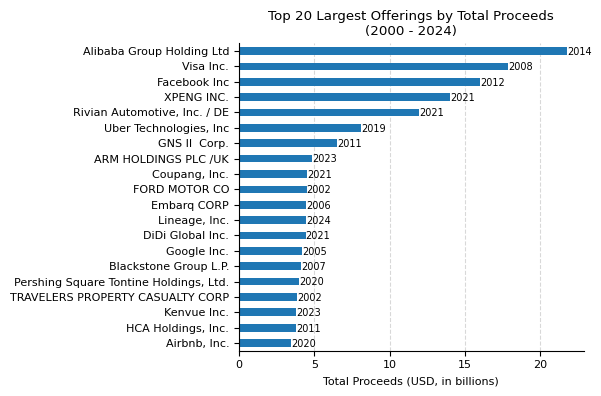

In [ ]:
pd.options.display.float_format = "{:,.0f}".format

top_20 = (
    df_pricing[df_pricing["formType"] == "424B4"]
    .sort_values(by="publicOfferingPrice.total", ascending=False)
    .drop_duplicates(subset="ticker")
    .head(20)
    .sort_values(by="publicOfferingPrice.total", ascending=True)
    .reset_index(drop=True)
)
top_20["year"] = top_20["filedAt"].dt.year
years = top_20["filedAt"].dt.year.to_list()

top_20.plot(kind="barh", x="entityName", y="publicOfferingPrice.total", figsize=(6, 4))

ax = plt.gca()
for p, year in zip(ax.patches, years):
    ax.annotate(
        year,
        (p.get_x() + p.get_width(), p.get_y()),
        xytext=(0, 0),
        textcoords="offset points",
        fontsize=7,
    )

ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: format(int(x) / 1000000000, ",.0f")))
ax.grid(True); ax.set_axisbelow(True); ax.grid(color="gray", linestyle="dashed", alpha=0.3)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.yaxis.grid(False), ax.legend().remove()
plt.title("Top 20 Largest Offerings by Total Proceeds\n(2000 - 2024)"); plt.xlabel("Total Proceeds (USD, in billions)")
plt.ylabel(""); plt.tight_layout(); plt.show()

In [ ]:
print("Top 20 Largest Offerings by Total Proceeds (2000 - 2024)")
top_20[["entityName", "publicOfferingPrice.total", "year"]].sort_values(
    by="publicOfferingPrice.total", ascending=False
).reset_index(drop=True)

Top 20 Largest Offerings by Total Proceeds (2000 - 2024)


,entityName,publicOfferingPrice.total,year
0,Alibaba Group Holding Ltd,"21,767,214,800",2014
1,Visa Inc.,"17,864,000,000",2008
2,Facebook Inc,"16,006,877,370",2012
3,XPENG INC.,"14,025,000,000",2021
4,"Rivian Automotive, Inc. / DE","11,934,000,000",2021
5,"Uber Technologies, Inc","8,100,000,000",2019
6,GNS II Corp.,"6,500,000,000",2011
7,ARM HOLDINGS PLC /UK,"4,870,500,000",2023
8,"Coupang, Inc.","4,550,000,000",2021
9,FORD MOTOR CO,"4,500,000,000",2002


### Aggregated Annual Offering Amounts by Year (2000 - 2024)

In [ ]:
total = (
    df_pricing[df_pricing["formType"] == "424B4"]
    .drop_duplicates(subset="ticker")[
        ["filedAt", "publicOfferingPrice.total", "accessionNo"]
    ]
    .copy()
)
total.drop(columns=["accessionNo"], inplace=True)
total["year"] = total["filedAt"].dt.year
total.drop(columns=["filedAt"], inplace=True)
total.fillna(0, inplace=True)
total = total.apply(pd.to_numeric, errors="coerce").fillna(0)
total

,publicOfferingPrice.total,year
8,0,2000
27,"143,500,000",2000
29,"80,000,000",2000
31,"75,000,000",2000
35,"40,750,000",2000
...,...,...
84869,"1,200,000",2024
84922,"6,400,000",2024
84926,"250,000,000",2024
84930,"300,000,000",2024


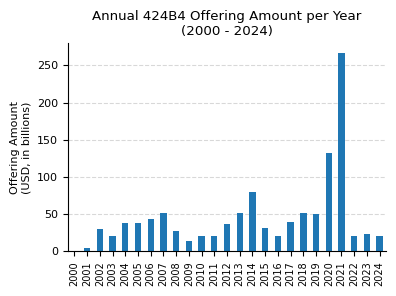

In [ ]:
total_by_year = total.groupby("year").sum()
total_by_year.plot(kind="bar", figsize=(4, 3))
plt.title("Annual 424B4 Offering Amount per Year\n(2000 - 2024)")
plt.ylabel("Offering Amount\n(USD, in billions)"); plt.xlabel("")
ax = plt.gca()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, p: format(int(x) / 1000000000, ",.0f")))
ax.get_legend().remove(), ax.grid(), ax.set_axisbelow(True)
ax.grid(True); ax.set_axisbelow(True); ax.grid(color="gray", linestyle="dashed", alpha=0.3)
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False); ax.xaxis.grid(False)
plt.setp(ax.get_xticklabels(), fontsize=7); plt.tight_layout(); plt.show()